In [3]:
import pandas as pd

# Le añadimos 'sep=";"' para decirle a Python que separe las columnas por el punto y coma
df = pd.read_csv("ine_viajeros_bruto.csv", encoding="latin1", encoding_errors="ignore", sep=";")

# Vemos cómo queda ahora
df.head()

,Puntos turísticos,Viajeros y pernoctaciones,Residencia,Periodo,Total
0,41091 Sevilla,Viajero,Residentes en España,2025M12,111.847
1,41091 Sevilla,Viajero,Residentes en España,2025M11,107.220
2,41091 Sevilla,Viajero,Residentes en España,2025M10,87.542
3,41091 Sevilla,Viajero,Residentes en España,2025M09,96.557
4,41091 Sevilla,Viajero,Residentes en España,2025M08,84.305


In [6]:
import numpy as np
import pandas as pd

# 1. Aseguramos que todo sea texto para poder limpiarlo
df["Total"] = df["Total"].astype(str).str.strip()

# 2. Quitamos los puntos de los millares (ej: 1.000 -> 1000)
df["Total"] = df["Total"].str.replace(".", "", regex=False)

# 3. Si hay celdas vacías o con un punto '.', las convertimos en "No Asignado" (NaN)
df["Total"] = df["Total"].replace(["", "."], np.nan)

# 4. Convertimos a float (decimal) para que no falle con los vacíos
df["Total"] = df["Total"].astype(float)

# Comprobamos cómo ha quedado la columna y sus tipos de datos
print(df["Total"].dtypes)
df.head()

float64


,Puntos turísticos,Viajeros y pernoctaciones,Residencia,Periodo,Total
0,41091 Sevilla,Viajero,Residentes en España,2025M12,111847.0
1,41091 Sevilla,Viajero,Residentes en España,2025M11,107220.0
2,41091 Sevilla,Viajero,Residentes en España,2025M10,87542.0
3,41091 Sevilla,Viajero,Residentes en España,2025M09,96557.0
4,41091 Sevilla,Viajero,Residentes en España,2025M08,84305.0


In [7]:
# Transformar a formato ancho (pivot)
df_pivot = df.pivot_table(
    index="Periodo",
    columns=["Viajeros y pernoctaciones", "Residencia"],
    values="Total",
    aggfunc="sum"
)

In [8]:
# Ver resultado
print(df_pivot.head())

Viajeros y pernoctaciones       Pernoctaciones                              \
Residencia                Residentes en España Residentes en el Extranjero   
Periodo                                                                      
2016M01                               148770.0                    155034.0   
2016M02                               191120.0                    163485.0   
2016M03                               212095.0                    225239.0   
2016M04                               169046.0                    292803.0   
2016M05                               166610.0                    306406.0   

Viajeros y pernoctaciones              Viajero                              
Residencia                Residentes en España Residentes en el Extranjero  
Periodo                                                                     
2016M01                                86635.0                     71245.0  
2016M02                               109556.0                     

In [9]:
# Aplanar nombre de columnas
df_pivot.columns = [
    f"{col1}_{col2}"
    for col1, col2 in df_pivot.columns
]

In [10]:
# Resetear índice
df_pivot = df_pivot.reset_index()

In [15]:
# 1. Renombrar las columnas combinadas
df_pivot = df_pivot.rename(
    columns={
        "Viajero_Residentes en España": "viajeros_nacionales",
        "Viajero_Residentes en el Extranjero": "viajeros_internacionales",
        "Viajero_Residentes en el extranjero": "viajeros_internacionales",
        "Pernoctaciones_Residentes en España": "pernoctaciones_nacionales",
        "Pernoctaciones_Residentes en el Extranjero": "pernoctaciones_internacionales",
        "Pernoctaciones_Residentes en el extranjero": "pernoctaciones_internacionales",
    }
)

# 2. Crear los totales
df_pivot["viajeros_totales"] = (
    df_pivot["viajeros_nacionales"] + df_pivot["viajeros_internacionales"]
)
df_pivot["pernoctaciones_totales"] = (
    df_pivot["pernoctaciones_nacionales"]
    + df_pivot["pernoctaciones_internacionales"]
)

# 3. Limpiar fechas (2025M12 -> 2025-12)
df_pivot["Periodo"] = df_pivot["Periodo"].astype(str).str.replace("M", "-")

# 4. Ordenar cronológicamente
df_pivot = df_pivot.sort_values("Periodo")

# 5. Guardar el archivo limpio en tu PC
df_pivot.to_csv("ine_viajeros_clean.csv", index=False)

# 6. Ver el resultado final en pantalla
df_pivot.head()

,Periodo,pernoctaciones_nacionales,pernoctaciones_internacionales,viajeros_nacionales,viajeros_internacionales,viajeros_totales,pernoctaciones_totales
0,2016-01,148770.0,155034.0,86635.0,71245.0,157880.0,303804.0
1,2016-02,191120.0,163485.0,109556.0,76389.0,185945.0,354605.0
2,2016-03,212095.0,225239.0,113635.0,101229.0,214864.0,437334.0
3,2016-04,169046.0,292803.0,107466.0,132910.0,240376.0,461849.0
4,2016-05,166610.0,306406.0,106962.0,144185.0,251147.0,473016.0


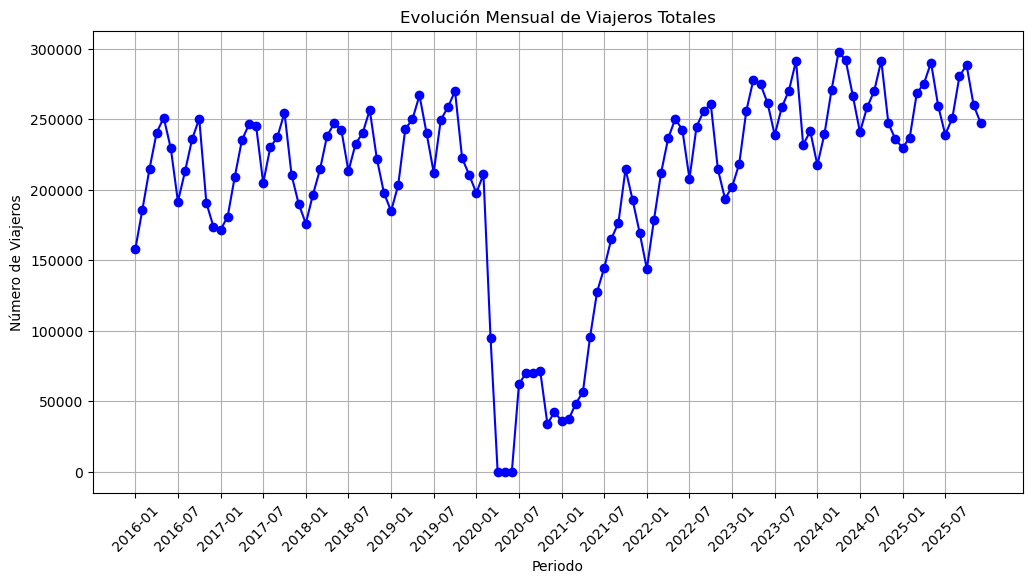

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargamos el archivo limpio que guardamos antes (así recuperamos los datos)
df_pivot = pd.read_csv("ine_viajeros_clean.csv")

# 2. Configuramos el tamaño del gráfico
plt.figure(figsize=(12, 6))

# 3. Dibujamos la línea de viajeros totales
plt.plot(
    df_pivot["Periodo"], df_pivot["viajeros_totales"], marker="o", color="blue"
)

# 4. Ajustes visuales
plt.title("Evolución Mensual de Viajeros Totales")
plt.xlabel("Periodo")
plt.ylabel("Número de Viajeros")
plt.xticks(
    rotation=45, ticks=df_pivot["Periodo"][::6]
)  # Muestra una fecha cada 6 meses para que no se amontonen
plt.grid(True)

# 5. Mostramos el gráfico
plt.show()

In [3]:
# Ver los 5 meses con más viajeros totales de toda la historia
top_meses = df_pivot.sort_values(by="viajeros_totales", ascending=False)
print("--- TOP 5 MESES CON MÁS VIAJEROS ---")
print(top_meses[["Periodo", "viajeros_totales"]].head())

# Calcular la media de pernoctaciones mensuales
media_pernoctaciones = df_pivot["pernoctaciones_totales"].mean()
print(f"\nLa media mensual de pernoctaciones es de: {media_pernoctaciones:,.0f}")

--- TOP 5 MESES CON MÁS VIAJEROS ---
     Periodo  viajeros_totales
99   2024-04          297895.0
100  2024-05          291690.0
105  2024-10          291620.0
93   2023-10          291461.0
112  2025-05          290245.0

La media mensual de pernoctaciones es de: 424,053


,Periodo,pernoctaciones_nacionales,pernoctaciones_internacionales,viajeros_nacionales,viajeros_internacionales,viajeros_totales,pernoctaciones_totales
119,2025-12,199937.0,322556.0,111847.0,135335.0,247182.0,522493.0
118,2025-11,190555.0,369508.0,107220.0,152670.0,259890.0,560063.0
117,2025-10,148530.0,479593.0,87542.0,200983.0,288525.0,628123.0
116,2025-09,158434.0,413298.0,96557.0,183881.0,280438.0,571732.0
115,2025-08,143076.0,380135.0,84305.0,166584.0,250889.0,523211.0


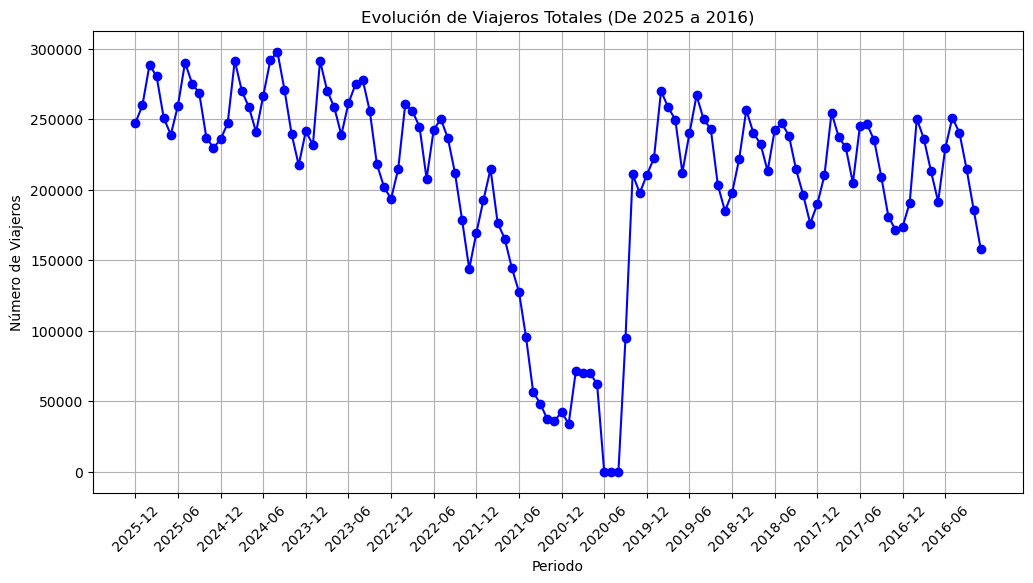

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Cargamos el archivo limpio
df_pivot = pd.read_csv("ine_viajeros_clean.csv")

# 2. ORDENAMOS: de 2025 a 2016 (las primeras filas serán 2025)
df_pivot = df_pivot.sort_values(by="Periodo", ascending=False)

# 3. Configuramos el tamaño del gráfico
plt.figure(figsize=(12, 6))

# 4. Dibujamos la línea (ahora irá de 2025 hacia atrás en el eje)
plt.plot(
    df_pivot["Periodo"], df_pivot["viajeros_totales"], marker="o", color="blue"
)

# 5. Ajustes visuales
plt.title("Evolución de Viajeros Totales (De 2025 a 2016)")
plt.xlabel("Periodo")
plt.ylabel("Número de Viajeros")
plt.xticks(rotation=45, ticks=df_pivot["Periodo"][::6])
plt.grid(True)

# 6. Guardamos el CSV con este nuevo orden inverso por si lo necesitas
df_pivot.to_csv("ine_viajeros_clean.csv", index=False)

# 7. Mostramos las primeras filas en pantalla (verás los datos de 2025 arriba)
df_pivot.head()